In [256]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Union

# 1. Data Loading

In [257]:
def load_data(
    source: Union[str, list],
) -> List[Dict]:

    samples = []

    # chuẩn hoá input
    if isinstance(source, list):
        paths = source
    elif os.path.isdir(source):
        paths = []
        for ext in ("*.jpg", "*.png", "*.jpeg"):
            paths.extend(glob.glob(os.path.join(source, ext)))
        paths.sort()
    else:
        paths = [source]

    for path in paths:
        ext = Path(path).suffix.lower()

        img = cv2.imread(path)
        if img is not None:
            samples.append({
                "name": Path(path).stem,
                "image": img
            })

    return samples

In [258]:
samples = load_data("input")

print("Total samples:", len(samples))
print("Example:", samples[0]["name"], samples[0]["image"].shape)

Total samples: 6
Example: boat1 (2592, 3888, 3)


# 2. Resize & Crop

## Mục tiêu
Chuẩn hoá kích thước ảnh về fixed size.

---

## Các bước

### 1. Scale (optional)
- Phóng to / thu nhỏ ảnh trước

### 2. Crop
- center crop → giữ vùng giữa
- ROI crop → cắt theo vùng chỉ định

### 3. Resize
- Đưa về kích thước cố định (vd: 512x512)

In [259]:
def resize_and_crop(
    image,
    target_size=(512, 512),
    crop=None,
    roi=None
):
    h, w = image.shape[:2]

    if crop == "center":
        side = min(h, w)
        y = (h - side) // 2
        x = (w - side) // 2
        image = image[y:y+side, x:x+side]

    elif crop == "roi" and roi is not None:
        x, y, rw, rh = roi
        image = image[y:y+rh, x:x+rw]

    image = cv2.resize(image, target_size)
    return image

(-0.5, 511.5, 511.5, -0.5)

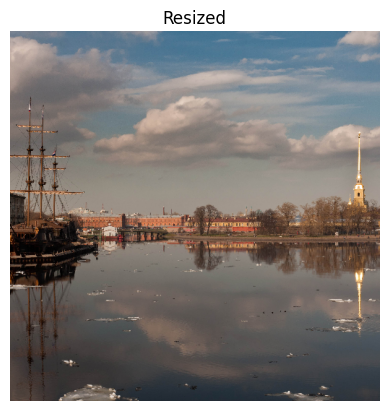

In [260]:
img = samples[0]["image"]

resized = resize_and_crop(img, crop="center")

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized")
plt.axis("off")

# 3. Color Space Conversion

## Mục tiêu
Chuyển đổi ảnh sang các không gian màu khác nhau.

---

## Các dạng
### Grayscale

In [261]:
def convert_color_spaces(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    return {
        "bgr": image,
        "gray": gray,
        "hsv": hsv
    }

(-0.5, 511.5, 511.5, -0.5)

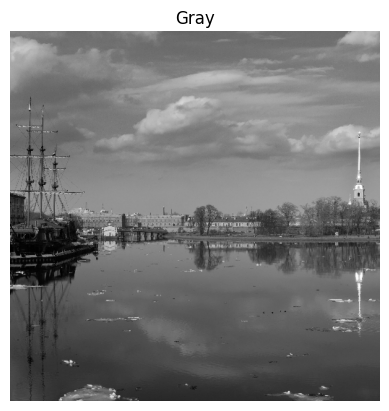

In [262]:
res = convert_color_spaces(resized)

plt.imshow(res["gray"], cmap="gray")
plt.title("Gray")
plt.axis("off")

# 4. Noise Reduction

## Mục tiêu
Giảm nhiễu trong ảnh để cải thiện chất lượng trước khi xử lý tiếp.

## Các phương pháp

### 1. Gaussian Blur

### 2. Median Blur

### 3. Bilateral Filter

In [263]:
def reduce_noise(image, method="gaussian", ksize=5):
    
    # đảm bảo ksize là số lẻ
    if ksize % 2 == 0:
        ksize += 1

    if method == "gaussian":
        return cv2.GaussianBlur(image, (ksize, ksize), 0)

    elif method == "median":
        return cv2.medianBlur(image, ksize)

    elif method == "bilateral":
        return cv2.bilateralFilter(image, 9, 75, 75)

    else:
        raise ValueError("Unknown noise method")

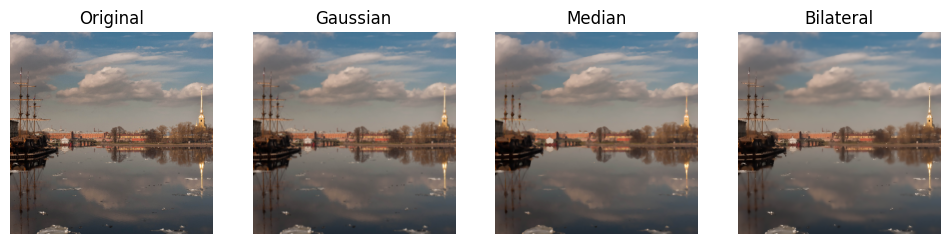

In [264]:
img = resized

gauss = reduce_noise(img, "gaussian")
median = reduce_noise(img, "median")
bilateral = reduce_noise(img, "bilateral")

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

imgs = [img, gauss, median, bilateral]
titles = ["Original", "Gaussian", "Median", "Bilateral"]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(cv2.cvtColor(imgs[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.show()

# 5. Lighting Adjustment

## Mục tiêu
Cải thiện độ sáng và độ tương phản của ảnh.

---

## Phương pháp

### 1. Histogram Equalization
### 2. CLAHE

---

## Tham số

- clipLimit:
  - thấp → ít nhiễu
  - cao → contrast mạnh

- tileGridSize:
  - kích thước vùng chia nhỏ

In [265]:
def adjust_lighting(
    image,
    method="clahe",
    clip_limit=2.0,
    tile_grid=(8,8)
):
    
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    if method == "clahe":
        clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid
        )
        l = clahe.apply(l)

    elif method == "histeq":
        l = cv2.equalizeHist(l)

    else:
        raise ValueError("Unknown lighting method")

    merged = cv2.merge([l, a, b])
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

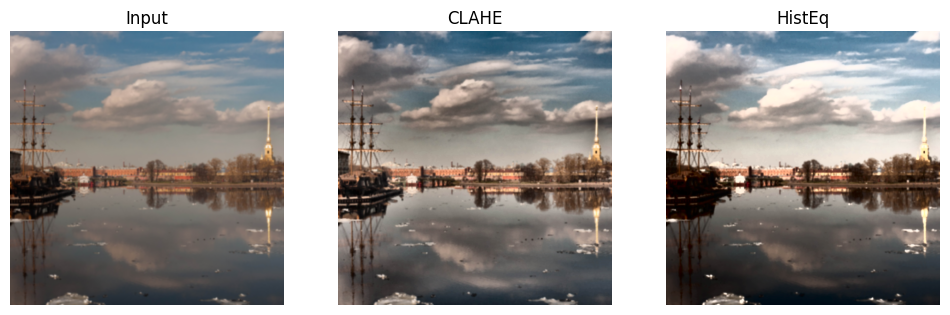

In [266]:
img = gauss

clahe = adjust_lighting(img, "clahe")
histeq = adjust_lighting(img, "histeq")

plt.figure(figsize=(12,4))

imgs = [img, clahe, histeq]
titles = ["Input", "CLAHE", "HistEq"]

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(cv2.cvtColor(imgs[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.show()

# 6. Edge Detection

## Mục tiêu
Phát hiện biên trong ảnh để xác định cấu trúc hình học.

## Phương pháp: Canny Edge Detection

## Tham số
- threshold1: ngưỡng thấp
- threshold2: ngưỡng cao

In [267]:
def detect_edges(image, low=100, high=200):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, low, high)
    return edges

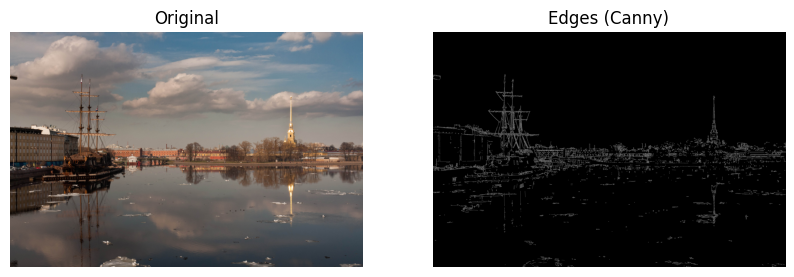

In [268]:
img = samples[0]["image"]

edges = detect_edges(img)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Edges (Canny)")
plt.axis("off")

plt.show()

# 7. Line Detection

## Mục tiêu
Phát hiện đường thẳng trong ảnh.

---

## Phương pháp: Hough Transform

In [269]:
def detect_lines(image):
    edges = detect_edges(image)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=100,
        minLineLength=50,
        maxLineGap=10
    )

    output = image.copy()

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(output, (x1,y1), (x2,y2), (0,255,0), 2)

    return output

(-0.5, 3887.5, 2591.5, -0.5)

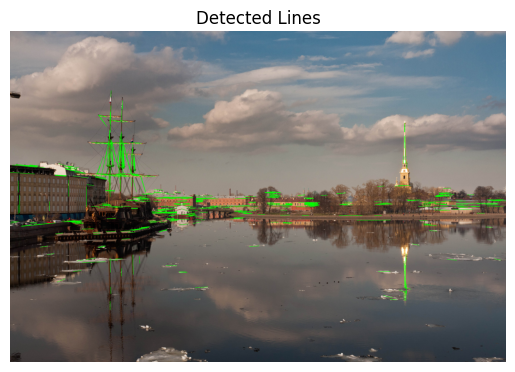

In [270]:
lines_img = detect_lines(img)

plt.imshow(cv2.cvtColor(lines_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines")
plt.axis("off")

# 8. Feature Detection & Matching

## Mục tiêu
Tìm điểm đặc trưng và so khớp giữa 2 ảnh.

---
## Phương pháp

### ORB (Oriented FAST + BRIEF)

## Matching

In [271]:
def extract_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(10000)

    kp, des = orb.detectAndCompute(gray, None)

    return kp, des

In [272]:
def match_features(img1, img2):
    kp1, des1 = extract_features(img1)
    kp2, des2 = extract_features(img2)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    matched_img = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        matches[:50],
        None,
        flags=2
    )

    return matched_img, kp1, kp2, matches

(-0.5, 7775.5, 2591.5, -0.5)

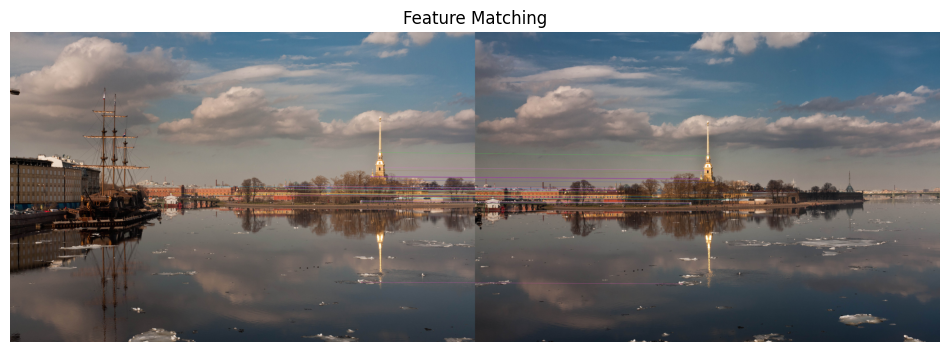

In [273]:
img1 = samples[0]["image"]
img2 = samples[1]["image"]

matched, kp1, kp2, matches = match_features(img1, img2)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(matched, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching")
plt.axis("off")

# 9. Homography Estimation

## Mục tiêu
Ước lượng phép biến đổi giữa 2 ảnh.

---

## Phương pháp
- RANSAC để loại outlier

In [274]:
def compute_homography(img1, img2):
    kp1, des1 = extract_features(img1)
    kp2, des2 = extract_features(img2)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.9 * n.distance:
            good.append(m)

    if len(good) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good])
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good])

        H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        return H

    return None

# 10. Panorama Stitching

## Mục tiêu
Ghép nhiều ảnh của cùng một cảnh thành ảnh toàn cảnh (panorama).

In [275]:
def stitch_with_center(images, center_idx):
    n = len(images)
    center_img = images[center_idx]

    h, w = center_img.shape[:2]

    # canvas lớn (an toàn cho nhiều ảnh)
    canvas_w = w * n * 2
    canvas = np.zeros((h, canvas_w, 3), dtype=np.uint8)

    # đặt center vào giữa
    offset_x = canvas_w // 2 - w // 2
    canvas[:, offset_x:offset_x + w] = center_img

    # ================= LEFT =================
    H_acc = np.eye(3)

    for i in range(center_idx - 1, -1, -1):
        H = compute_homography(images[i], images[i+1])

        if H is None:
            print(f"❌ Left fail at {i}")
            continue

        H_acc = H @ H_acc

        warped = cv2.warpPerspective(images[i], H_acc, (canvas_w, h))
        mask = (warped.sum(axis=2) > 0)
        canvas[mask] = warped[mask]

    # ================= RIGHT =================
    H_acc = np.eye(3)

    for i in range(center_idx + 1, n):
        H = compute_homography(images[i-1], images[i])

        if H is None:
            print(f"❌ Right fail at {i}")
            continue

        H_inv = np.linalg.inv(H)
        H_acc = H_inv @ H_acc

        warped = cv2.warpPerspective(images[i], H_acc, (canvas_w, h))
        mask = (warped.sum(axis=2) > 0)
        canvas[mask] = warped[mask]

    return canvas

Center = 0


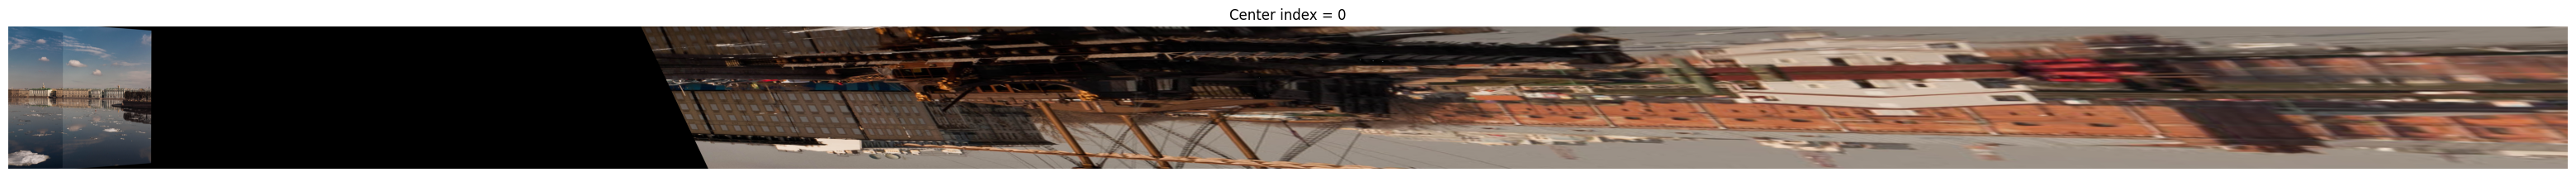

Center = 1


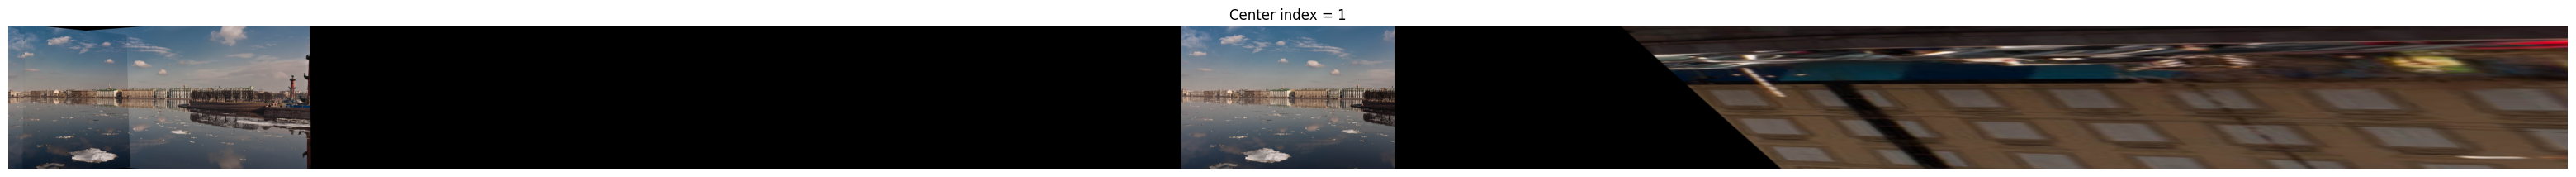

Center = 2


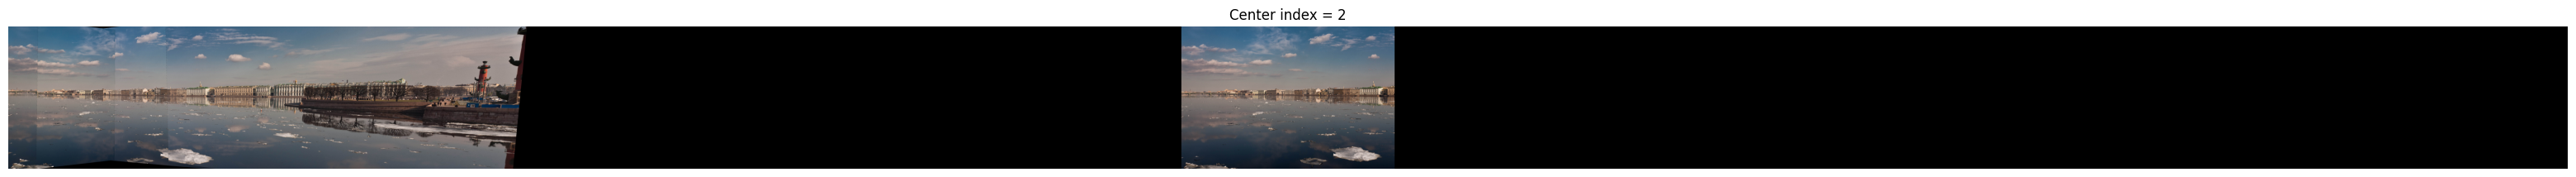

Center = 3


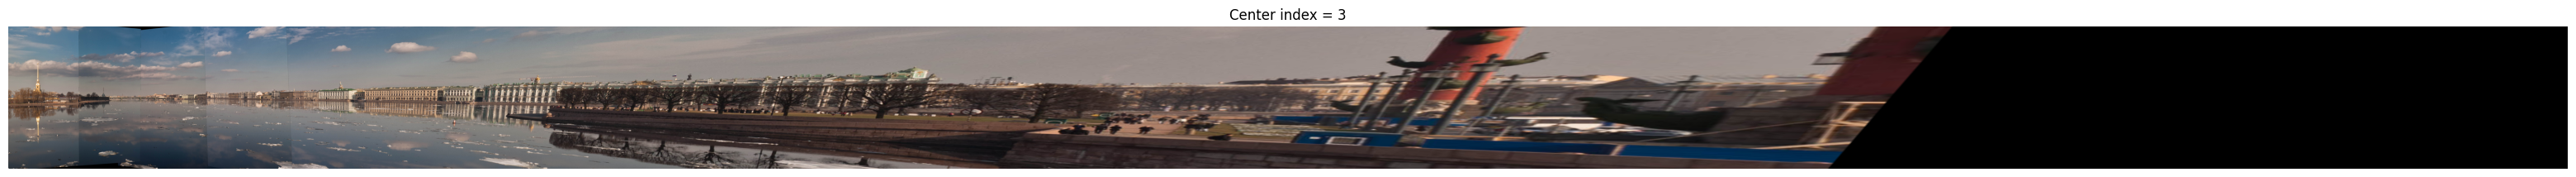

Center = 4


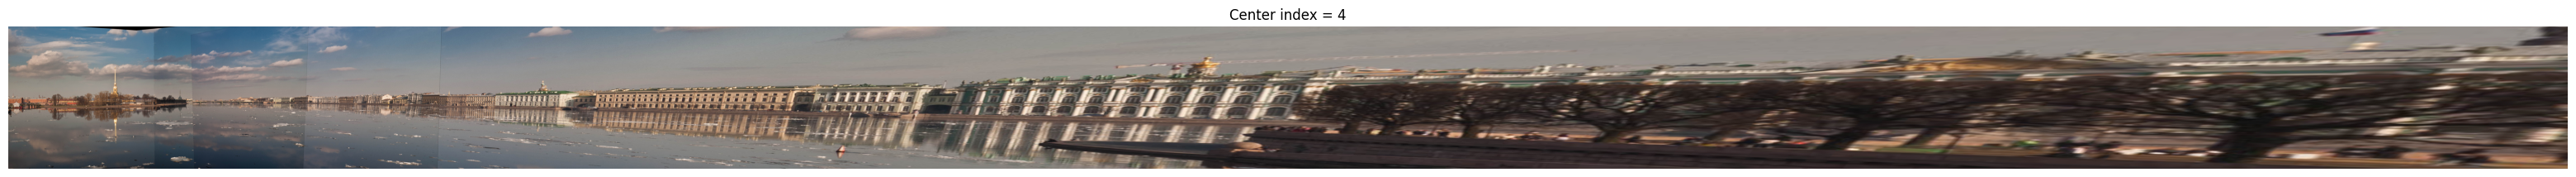

Center = 5


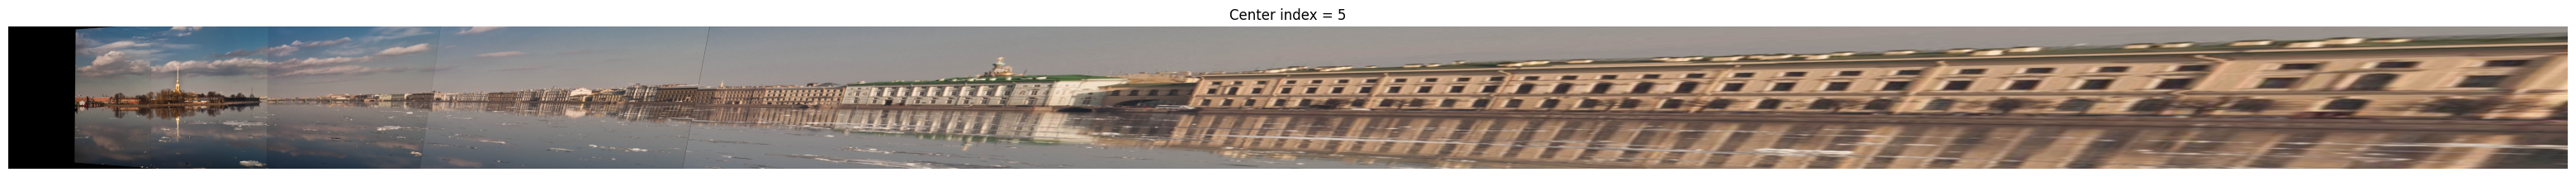

In [279]:
imgs = [
    samples[5]["image"],
    samples[4]["image"],
    samples[3]["image"],
    samples[2]["image"],
    samples[1]["image"],
    samples[0]["image"],
]

for center_idx in range(len(imgs)):
    print(f"Center = {center_idx}")

    pano = stitch_with_center(imgs, center_idx=center_idx)

    plt.figure(figsize=(40,20))
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.title(f"Center index = {center_idx}")
    plt.axis("off")
    plt.show()